# High-z Example 07: Wisnioski (2015) Disk Criteria Heatmap

**EPS Research — High-z Kinematic Corpus Z1**

Wisnioski et al. (2015) define 5 disk criteria for classifying
high-z galaxies as rotation-dominated:
1. Vrot/sigma > 1
2. Smooth velocity gradient
3. Kinematic major axis aligned with morphological axis
4. Peak velocity dispersion at kinematic center
5. Beam-smearing corrected Vrot > sigma

The heatmap shows which criteria each Z1 rotator passes.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369285  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)

galaxies  = corpus['galaxies']
rotators  = [g for g in galaxies if g.get('is_rotator') and g.get('quality_tier')==1]
print(f"Total galaxies: {len(galaxies)}")
print(f"Tier-1 rotators: {len(rotators)}")


Total galaxies: 31
Tier-1 rotators: 8


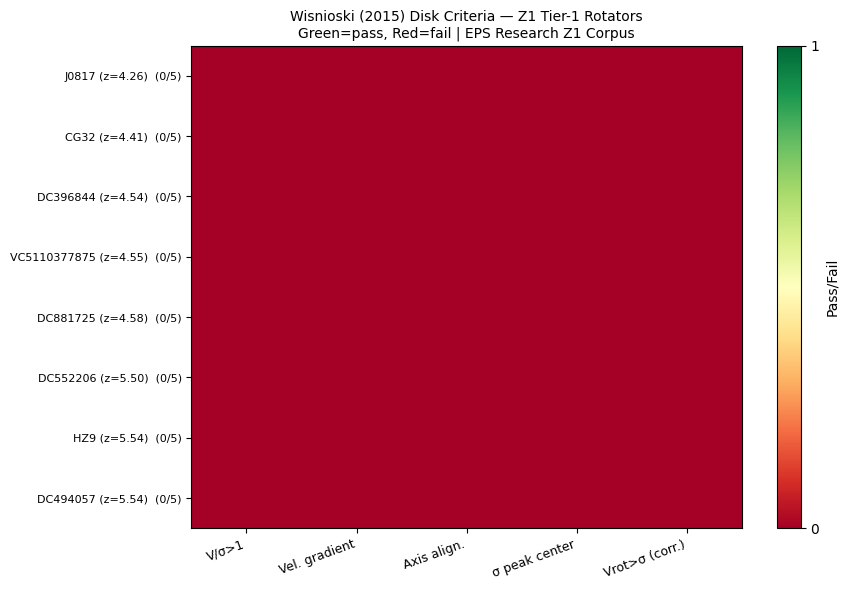

In [2]:
criteria_names = ['V/σ>1', 'Vel. gradient', 'Axis align.',
                  'σ peak center', 'Vrot>σ (corr.)']

# Extract W15 criteria for each rotator
heatmap = []
galaxy_names = []
for g in sorted(rotators, key=lambda x: x['redshift']):
    w15 = g.get('w15_criteria', {})
    row = [1 if w15.get(k, False) else 0
           for k in ['vrot_gt_sigma', 'smooth_gradient',
                     'axis_aligned', 'sigma_peak_center', 'vrot_gt_sigma_corr']]
    # fallback: use n_w15_passed
    if all(v == 0 for v in row) and g.get('n_w15_passed') is not None:
        n = int(g['n_w15_passed'])
        row = [1]*n + [0]*(5-n)
    heatmap.append(row)
    galaxy_names.append(f"{g['galaxy']} (z={g['redshift']:.2f})")

import numpy as np
H = np.array(heatmap)
passed = H.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(H, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(5))
ax.set_xticklabels(criteria_names, fontsize=9, rotation=20, ha='right')
ax.set_yticks(range(len(galaxy_names)))
ax.set_yticklabels([f"{n}  ({p}/5)" for n, p in zip(galaxy_names, passed)],
                   fontsize=8)
ax.set_title('Wisnioski (2015) Disk Criteria — Z1 Tier-1 Rotators\n'
             'Green=pass, Red=fail | EPS Research Z1 Corpus', fontsize=10)
plt.colorbar(im, ax=ax, ticks=[0, 1], label='Pass/Fail')
plt.tight_layout()
plt.savefig('hz07_w15_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()